Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


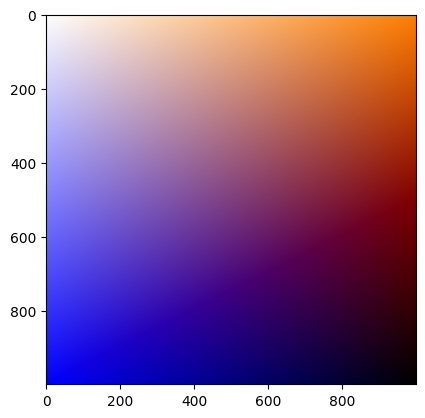

In [37]:

import numpy as np
import matplotlib.pyplot as plt


def blend_arrays(array0, array1, xmin, xmax):

    array0, array1 = np.log10(array0), np.log10(array1)
    
    # Normalize arrays between 0 and 1
    a0 = (array0 - xmin) / (xmax - xmin)
    a1 = (array1 - xmin) / (xmax - xmin)
    a0[np.isnan(a0)] = 0
    a1[np.isnan(a1)] = 0 
    a0[a0 > 1] = 1
    a1[a1 > 1] = 1 
    a0[a0 < 0] = 0
    a1[a1 < 0] = 0 

    # Create RGB image: R from array1, B from array0, G optional
    rgb = np.ones((array0.shape[0], array0.shape[1], 3))
    rgb[..., 0] -= a0   # Red channel = array1
    rgb[..., 1] -= (a0 + a1*0.5)   # Green channel = array1
    rgb[..., 2] -= a1   # Blue channel = array0

    # # Create RGB image: R from array1, B from array0, G optional
    # rgb = np.ones((array0.shape[0], array0.shape[1], 3))
    # rgb[..., 1] -= a1*0.5   # Green channel = array1
    # rgb[..., 2] -= a1   # Blue channel = array0

    # # Create RGB image: R from array1, B from array0, G optional
    # rgb = np.ones((array0.shape[0], array0.shape[1], 3))
    # rgb[..., 0] -= a0   # Red channel = array1
    # rgb[..., 1] -= a0   # Green channel = array1

    return rgb

nx, ny = 1000, 1000
vmin, vmax = np.log10(1/24), np.log10(365.25*1.4)
max_inundation_duration = np.tile(10**np.linspace(vmin, vmax, nx), reps = ny).reshape(ny,nx).T
max_emergent_druation = np.tile(10**np.linspace(vmin, vmax, ny), reps = nx).reshape(nx,ny)

rgb = blend_arrays(max_inundation_duration, max_emergent_druation, vmin, vmax)

plt.imshow(rgb, vmin = vmin, vmax = vmax)
plt.show()